### Завдання 1. Обрати унікальний датасет з UCI
Було обрано **Hepatitis**.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def loading_dataset(file_path):
    columns = [
        'Class', 'Age', 'Sex', 'Steroid', 'Antivirals', 'Fatigue', 'Malaise', 
        'Anorexia', 'Liver Big', 'Liver Firm', 'Spleen Palpable', 'Spiders', 
        'Ascites', 'Varices', 'Bilirubin', 'Alk Phosphate', 'SGOT', 'Albumin', 
        'Prothrombin', 'Histology'
    ]
    
    df = pd.read_csv(file_path, names=columns, na_values='?')
    
    return df

df_url="https://archive.ics.uci.edu/ml/machine-learning-databases/hepatitis/hepatitis.data"
df_hepatitis = loading_dataset(df_url)
df_hepatitis.head(15)

,Class,Age,Sex,Steroid,Antivirals,Fatigue,Malaise,Anorexia,Liver Big,Liver Firm,Spleen Palpable,Spiders,Ascites,Varices,Bilirubin,Alk Phosphate,SGOT,Albumin,Prothrombin,Histology
0,2,30,2,1.0,2,2.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0,1.0,85.0,18.0,4.0,NaN,1
1,2,50,1,1.0,2,1.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0,0.9,135.0,42.0,3.5,NaN,1
2,2,78,1,2.0,2,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,0.7,96.0,32.0,4.0,NaN,1
3,2,31,1,NaN,1,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,0.7,46.0,52.0,4.0,80.0,1
4,2,34,1,2.0,2,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,NaN,200.0,4.0,NaN,1
5,2,34,1,2.0,2,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,0.9,95.0,28.0,4.0,75.0,1
6,1,51,1,1.0,2,1.0,2.0,1.0,2.0,2.0,1.0,1.0,2.0,2.0,NaN,NaN,NaN,NaN,NaN,1
7,2,23,1,2.0,2,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,NaN,NaN,NaN,NaN,1
8,2,39,1,2.0,2,1.0,2.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,0.7,NaN,48.0,4.4,NaN,1
9,2,30,1,2.0,2,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,NaN,120.0,3.9,NaN,1


### Завдання 2. Здійснити Data Cleaning
Видалення пацієнтів без повних даних, заміна данихх стовпців на зрозуміліші, заміна деяких рядкових даних на дробові.

In [2]:
def clean_dataset(df):
    df_clean = df.copy()

    numeric_columns = ['Age', 'Bilirubin', 'Alk Phosphate', 'SGOT', 'Albumin', 'Prothrombin']
    
    for col in numeric_columns:
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce').astype(float)

    for col in numeric_columns:
        median_value = df_clean[col].median()
        df_clean[col] = df_clean[col].fillna(median_value)

    df_clean['Class'] = df_clean['Class'].map({1: 'Die', 2: 'Live'})
    df_clean['Sex'] = df_clean['Sex'].map({1: 'Male', 2: 'Female'})

    df_clean = df_clean.dropna()
    
    return df_clean

df_hepatitis_cleaned = clean_dataset(df_hepatitis)

print(f"Кількість пацієнтів до очищення: {len(df_hepatitis)}\n")
print(f"Кількість пацієнтів після видалення не повністю заповнених даних: {len(df_hepatitis_cleaned)}\n")

df_hepatitis_cleaned.head(5)

Кількість пацієнтів до очищення: 155

Кількість пацієнтів після видалення не повністю заповнених даних: 80



,Class,Age,Sex,Steroid,Antivirals,Fatigue,Malaise,Anorexia,Liver Big,Liver Firm,Spleen Palpable,Spiders,Ascites,Varices,Bilirubin,Alk Phosphate,SGOT,Albumin,Prothrombin,Histology
5,Live,34.0,Male,2.0,2,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,0.9,95.0,28.0,4.0,75.0,1
10,Live,39.0,Male,1.0,1,2.0,2.0,2.0,1.0,1.0,2.0,2.0,2.0,2.0,1.3,78.0,30.0,4.4,85.0,1
11,Live,32.0,Male,2.0,1,1.0,2.0,2.0,2.0,1.0,2.0,1.0,2.0,2.0,1.0,59.0,249.0,3.7,54.0,1
12,Live,41.0,Male,2.0,1,1.0,2.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,0.9,81.0,60.0,3.9,52.0,1
13,Live,30.0,Male,2.0,2,1.0,2.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,2.2,57.0,144.0,4.9,78.0,1


### Завдання 3. Побудувати графіки залежності одного integer/real атрибута від іншого (lineplot, scatter etc).
Графік ScatterPlot + Trendline. Залежність Альбуміну від Білірубіну

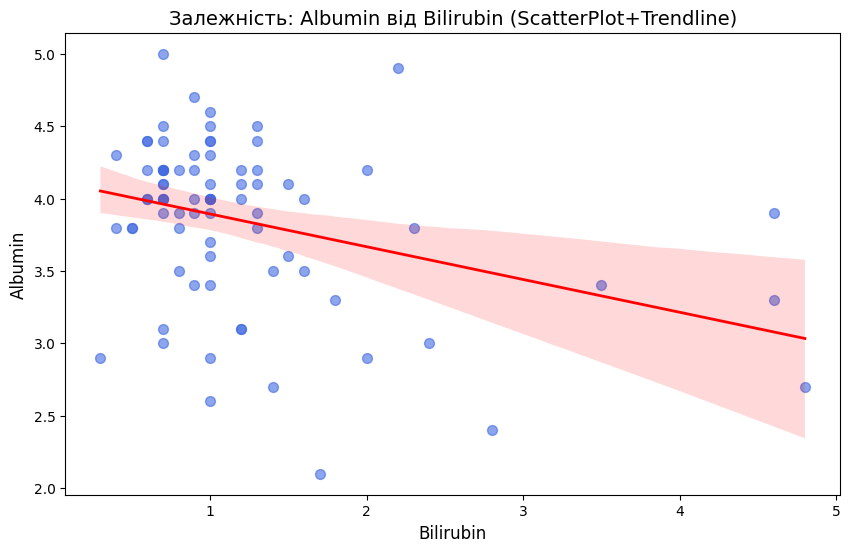

In [3]:
def plot_scatter(df, x_col, y_col):

    plt.figure(figsize=(10, 6))
    
    sns.regplot(data=df, x=x_col, y=y_col, scatter_kws={'alpha': 0.6, 'color': 'royalblue', 's': 50}, line_kws={'color': 'red', 'linewidth': 2})

    plt.title(f'Залежність: {y_col} від {x_col} (ScatterPlot+Trendline)', fontsize=14)
    plt.xlabel(x_col, fontsize=12)
    plt.ylabel(y_col, fontsize=12)
    plt.show()

plot_scatter(df_hepatitis_cleaned, x_col='Bilirubin', y_col='Albumin')

### Завдання 4. Побудувати гістограму по одному з атрибутів, що буде показувати на кількість елементів, що знаходяться у 5 діапазонах, які ви задасте.
Розподіл кількості пацієнтів за їх віком на 5 діапазонів. Також було накладено лінію медіани.

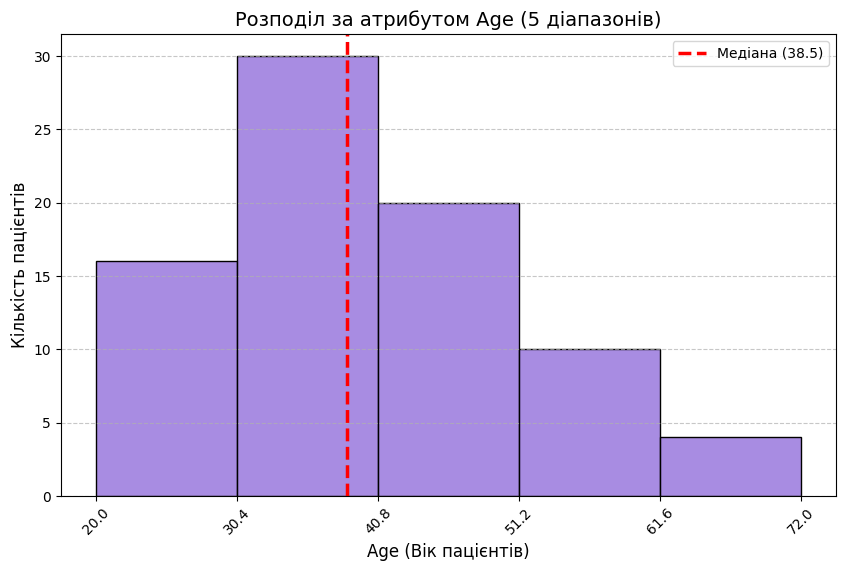


Таблиця деталей діапазонів (Bin Details):


,Start (Age),End (Age),Patient Count
0,20.0,30.4,16
1,30.4,40.8,30
2,40.8,51.2,20
3,51.2,61.6,10
4,61.6,72.0,4


In [4]:
def plot_histogram(df, column='Age', num_bins=5):
    plt.figure(figsize=(10, 6))

    counts, bins = np.histogram(df[column].dropna(), bins=num_bins)
    
    sns.histplot(data=df, x=column, bins=bins, color='mediumpurple', edgecolor='black',alpha=0.8)
    
    median_val = df[column].median()
    plt.axvline(median_val, color='red', linestyle='dashed', linewidth=2.5, label=f'Медіана ({median_val:.1f})')
    
    plt.title(f'Розподіл за атрибутом {column} ({num_bins} діапазонів)', fontsize=14)
    plt.xlabel(f'{column} (Вік пацієнтів)', fontsize=12)
    plt.ylabel('Кількість пацієнтів', fontsize=12)
    
    plt.xticks(bins, rotation=45) 
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    plt.legend()
    
    plt.show()
    
    bin_df = pd.DataFrame({
        f'Start ({column})': np.round(bins[:-1], 1), 
        f'End ({column})': np.round(bins[1:], 1), 
        'Patient Count': counts.astype(int)
    })
    
    print("\nТаблиця деталей діапазонів (Bin Details):")
    display(bin_df)

# Викликаємо функцію
plot_histogram(df_hepatitis_cleaned, column='Age', num_bins=5)

### Завдання 5. Збудувати графіки, використовуючи приклади, наведені у статті Medium
Було обрано:
1. **Multidimensional Pairplot** - для попарного порівняння головних клінічних характеристик з урахуванням факту виживання пацієнта.
2. **4d Bubble Chart** - для одночасної візуалізації чотирьох параметрів (вік, білірубін, рівень альбуміну та клас виживання).
3. **Groupe Violin Plot** - для порівняння щільності розподілу рівня альбуміну серед чоловіків та жінок
4. **Correlation Heatmap** - для пошуку взаємозв'язків між ключовими числовими медичними атрибутами (вік, білірубін, альбумін, протромбін тощо).

Multidimensional Pairplot


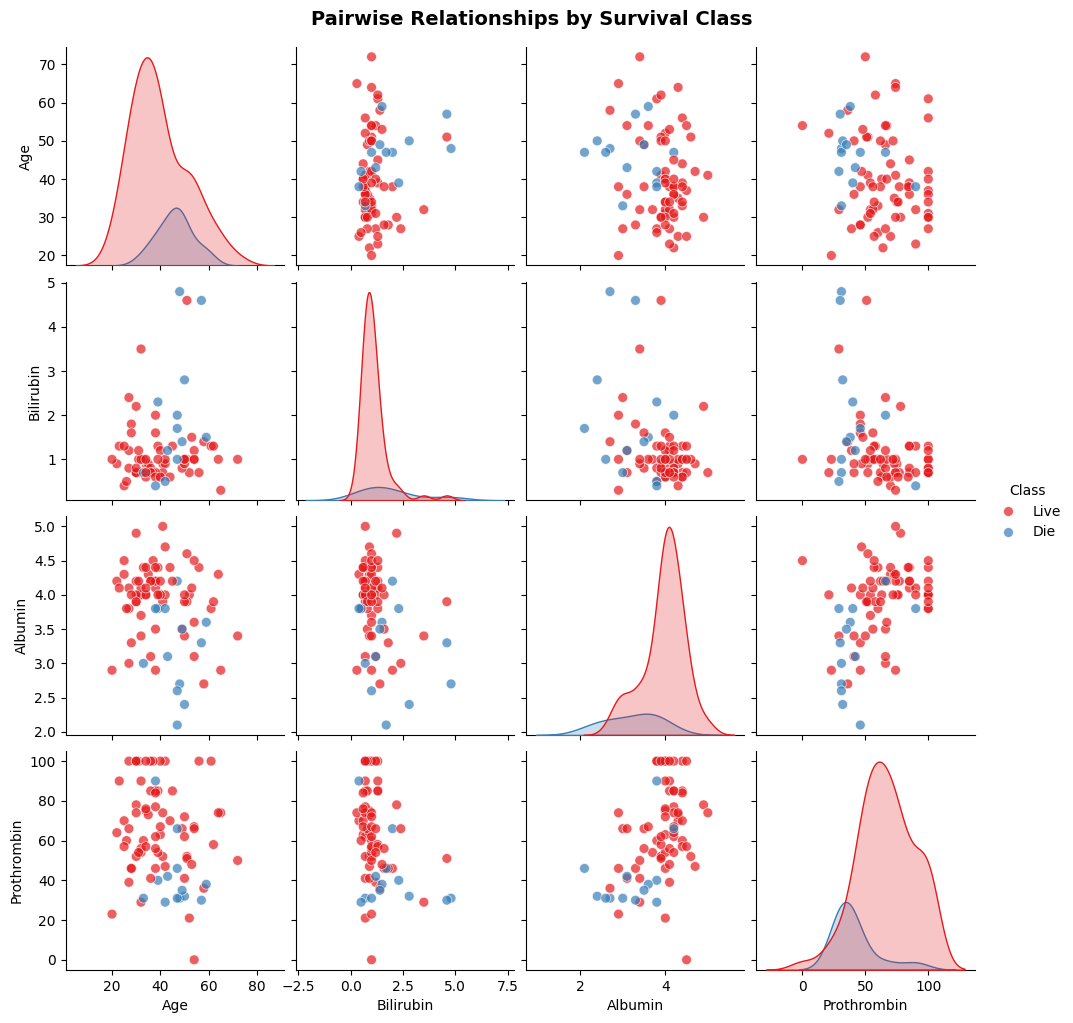


4D Bubble Chart


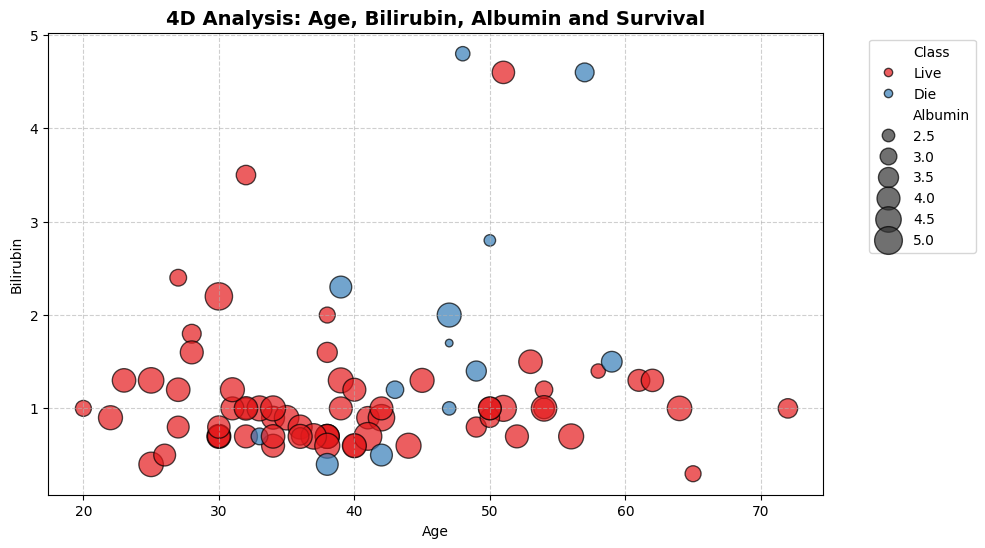


Grouped Violin Plot


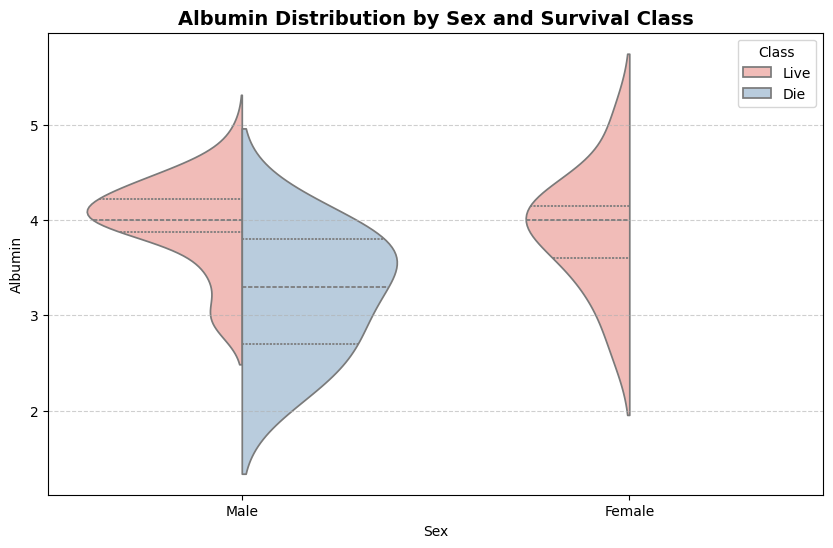


Correlation Heatmap


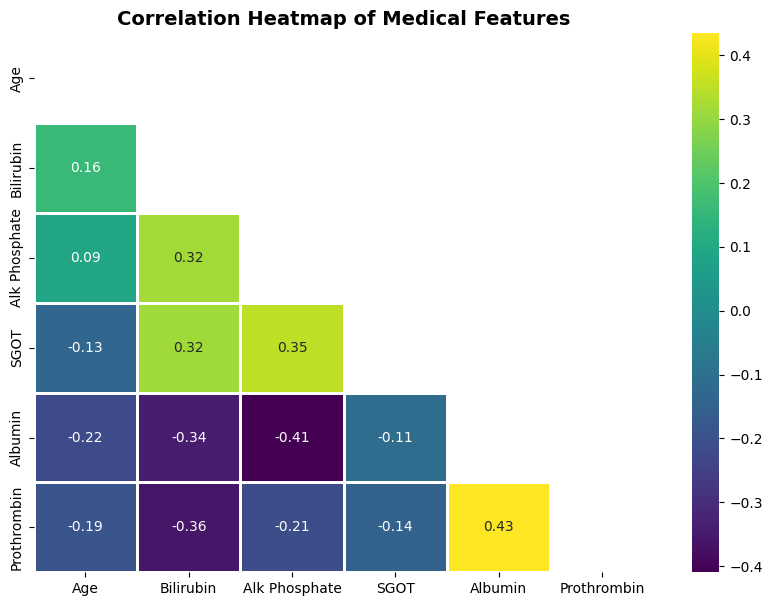

In [5]:
print("Multidimensional Pairplot")
pair_features = ['Class', 'Age', 'Bilirubin', 'Albumin', 'Prothrombin']
pair_plot = sns.pairplot(df_hepatitis_cleaned[pair_features].dropna(), hue='Class', palette='Set1', diag_kind='kde', plot_kws={'alpha': 0.7, 's': 50, 'edgecolor': 'w'},diag_kws={'fill': True})
pair_plot.fig.suptitle('Pairwise Relationships by Survival Class', y=1.02, fontsize=14, fontweight='bold')
plt.show()


print("\n4D Bubble Chart")
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_hepatitis_cleaned, x='Age', y='Bilirubin', hue='Class', size='Albumin', sizes=(30, 400), alpha=0.7, palette='Set1',edgecolor='black')

plt.title('4D Analysis: Age, Bilirubin, Albumin and Survival', fontsize=14, fontweight='bold')

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') 
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print("\nGrouped Violin Plot")

plt.figure(figsize=(10, 6))
sns.violinplot(data=df_hepatitis_cleaned, x='Sex', y='Albumin', hue='Class', split=True, inner='quartile', palette='Pastel1')

plt.title('Albumin Distribution by Sex and Survival Class', fontsize=14, fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

print("\nCorrelation Heatmap")
plt.figure(figsize=(10, 7))
num_features = ['Age', 'Bilirubin', 'Alk Phosphate', 'SGOT', 'Albumin', 'Prothrombin']
corr_matrix = df_hepatitis_cleaned[num_features].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='viridis', linewidths=1, linecolor='white')
plt.title('Correlation Heatmap of Medical Features', fontsize=14, fontweight='bold')
plt.show()

### Завдання 6. Побудувати інші графіки, що покажуть корисну інформацію про датасет.
1. **Barplot** - для наочного порівняння середнього рівня протромбіну за різними віковими групами.
2. **Boxplot + Stripplot** - для аналізу розподілу рівня альбуміну залежно від класу виживання (Live/Die) з відображенням кожної окремої точки даних (кожного пацієнта).


Barplot з анотаціями значень (Average Prothrombin by Age Group)


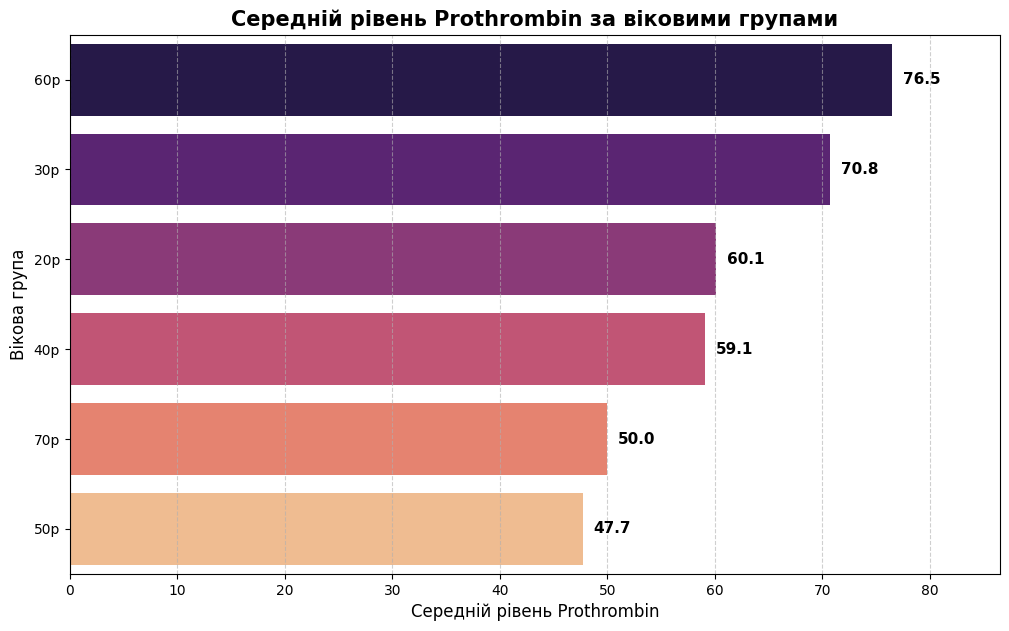


Boxplot з накладеним Stripplot (Albumin Distribution by Survival Class)


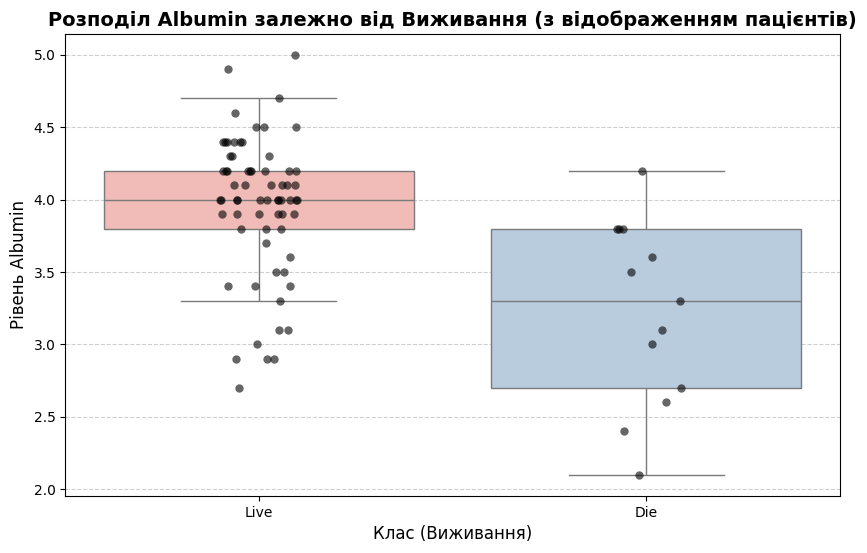

In [6]:
df_hepatitis_cleaned['Age Group'] = (df_hepatitis_cleaned['Age'] // 10 * 10).astype(int).astype(str) + 's'

print("1. Barplot з анотаціями значень (Average Prothrombin by Age Group)")
plt.figure(figsize=(12, 7))

avg_prothrombin = df_hepatitis_cleaned.groupby('Age Group')['Prothrombin'].mean().sort_values(ascending=False).reset_index()

ax = sns.barplot(data=avg_prothrombin, x='Prothrombin', y='Age Group', hue='Age Group', palette='magma', legend=False)

plt.title('Середній рівень Prothrombin за віковими групами', fontsize=15, fontweight='bold')
plt.xlabel('Середній рівень Prothrombin', fontsize=12)
plt.ylabel('Вікова група', fontsize=12)

for p in ax.patches:
    width = p.get_width()
    ax.text(width + 1, p.get_y() + p.get_height() / 2, f'{width:.1f}', ha='left', va='center', fontsize=11, fontweight='bold')

plt.xlim(0, avg_prothrombin['Prothrombin'].max() + 10)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

print("\n2. Boxplot з накладеним Stripplot (Albumin Distribution by Survival Class)")
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_hepatitis_cleaned, 
    x='Class', 
    y='Albumin', 
    hue='Class', 
    palette='Pastel1', 
    fliersize=0, 
    legend=False
)

sns.stripplot(
    data=df_hepatitis_cleaned, 
    x='Class', 
    y='Albumin', 
    color='black', 
    alpha=0.6, 
    size=6, 
    jitter=True 
)

plt.title('Розподіл Albumin залежно від Виживання (з відображенням пацієнтів)', fontsize=14, fontweight='bold')
plt.xlabel('Клас (Виживання)', fontsize=12)
plt.ylabel('Рівень Albumin', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

df_hepatitis_cleaned = df_hepatitis_cleaned.drop(columns=['Age Group'])